# Deep Learning–Based Detection of Population-Level Stress Signals in Social Media  
## Milestone C: Functional Prototype

**Student:** Matias Romero  
**Course:** AIT-716 Advanced Artificial Intelligence  
**Date:** August 1, 2026  

### Notebook purpose
This notebook implements the Milestone B design as a working text-classification pipeline. It:

1. Loads and audits the Dreaddit training and test files.
2. Removes exact training duplicates and training records that overlap the held-out test set.
3. Applies conservative text normalization.
4. Creates a stratified training/validation split.
5. Trains a majority-class reference and a TF-IDF logistic-regression baseline.
6. Fine-tunes `distilbert-base-uncased` for binary stress-signal classification.
7. Logs learning curves and evaluates the model with accuracy, precision, recall, F1, ROC-AUC, a confusion matrix, and sample predictions.

> **Important:** The output is a linguistic stress-signal classifier, not a clinical diagnostic system.

## 1. Environment setup

Note: Google Colab, run T4 GPU. Cell below installs the two Hugging Face libraries needed:

*   transformers provides the DistilBERT tokenizer, pretrained model, Trainer, and training utilities.
*  accelerate helps Hugging Face manage CPU/GPU execution, mixed precision, and device placement.




In [3]:
# Install packages needed for the transformer prototype.
!pip -q install "transformers>=4.45,<5" "accelerate>=1.0,<2"

In [4]:
from pathlib import Path
import re
import random
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    roc_auc_score, RocCurveDisplay
)
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

Python: 3.12.13
PyTorch: 2.11.0+cu128
Device: cuda


## 2. Dataset loading

The notebook first looks for local files named `dreaddit-train.csv` and `dreaddit-test.csv`.  
When they are not present, it loads the same public fallback URLs used in Milestone B.

Note: Milestone B contains the same unmodified datasets from online so in this case we will let it download again.

In [5]:
DATA_DIR = Path(".")
TRAIN_FILE = DATA_DIR / "dreaddit-train.csv"
TEST_FILE = DATA_DIR / "dreaddit-test.csv"

TRAIN_URL = (
    "https://raw.githubusercontent.com/zhixin-lim/DSA4262/main/"
    "Individual%20Assignment%202/data/dreaddit-train.csv"
)
TEST_URL = (
    "https://raw.githubusercontent.com/zhixin-lim/DSA4262/main/"
    "Individual%20Assignment%202/data/dreaddit-test.csv"
)

def load_csv(local_path: Path, fallback_url: str) -> pd.DataFrame:
    if local_path.exists():
        print(f"Loading local file: {local_path}")
        return pd.read_csv(local_path)
    print(f"{local_path.name} not found locally; loading public fallback URL.")
    return pd.read_csv(fallback_url)

train_raw = load_csv(TRAIN_FILE, TRAIN_URL)
test_raw = load_csv(TEST_FILE, TEST_URL)

print("Raw training shape:", train_raw.shape)
print("Raw test shape:", test_raw.shape)
train_raw[["subreddit", "text", "label", "confidence"]].head(3)

dreaddit-train.csv not found locally; loading public fallback URL.
dreaddit-test.csv not found locally; loading public fallback URL.
Raw training shape: (2838, 116)
Raw test shape: (715, 116)


,subreddit,text,label,confidence
0,ptsd,"He said he had not felt that way before, sugge...",1,0.8
1,assistance,"Hey there r/assistance, Not sure if this is th...",0,1.0
2,ptsd,My mom then hit me with the newspaper and it s...,1,0.8


## 3. Data-quality audit and leakage control

Milestone B identified 18 duplicate training texts and three texts shared by the training and test files.  
This implementation removes exact duplicate training texts and excludes any training text appearing in the held-out test set.

In [6]:
quality_before = pd.Series({
    "missing training text": train_raw["text"].isna().sum(),
    "missing test text": test_raw["text"].isna().sum(),
    "duplicate training text": train_raw.duplicated(subset=["text"]).sum(),
    "duplicate test text": test_raw.duplicated(subset=["text"]).sum(),
    "train/test overlapping text": len(
        set(train_raw["text"]).intersection(set(test_raw["text"]))
    ),
    "unexpected training labels": (~train_raw["label"].isin([0, 1])).sum(),
    "unexpected test labels": (~test_raw["label"].isin([0, 1])).sum(),
})
quality_before.to_frame("count")

,count
missing training text,0
missing test text,0
duplicate training text,18
duplicate test text,0
train/test overlapping text,3
unexpected training labels,0
unexpected test labels,0


In [7]:
train_df = train_raw.dropna(subset=["text", "label"]).copy()
test_df = test_raw.dropna(subset=["text", "label"]).copy()

# Remove exact duplicate training texts, keeping the first occurrence.
train_df = train_df.drop_duplicates(subset=["text"], keep="first").copy()

# Prevent identical held-out test language from appearing during training.
test_text_set = set(test_df["text"])
train_df = train_df.loc[~train_df["text"].isin(test_text_set)].copy()

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

quality_after = pd.Series({
    "clean training rows": len(train_df),
    "test rows": len(test_df),
    "remaining duplicate training text": train_df.duplicated(subset=["text"]).sum(),
    "remaining train/test overlap": len(
        set(train_df["text"]).intersection(set(test_df["text"]))
    ),
})
quality_after.to_frame("count")

,count
clean training rows,2817
test rows,715
remaining duplicate training text,0
remaining train/test overlap,0


## 4. Conservative preprocessing

URLs are replaced with a stable placeholder and repeated whitespace is collapsed.  
Punctuation, capitalization, contractions, negation, pronouns, and emotionally meaningful wording are preserved.

In [8]:
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
WHITESPACE_PATTERN = re.compile(r"\s+")

def normalize_text(text: str) -> str:
    text = str(text)
    text = URL_PATTERN.sub("[URL]", text)
    return WHITESPACE_PATTERN.sub(" ", text).strip()

train_df["clean_text"] = train_df["text"].map(normalize_text)
test_df["clean_text"] = test_df["text"].map(normalize_text)

label_table = pd.DataFrame({
    "training": train_df["label"].value_counts().sort_index(),
    "test": test_df["label"].value_counts().sort_index(),
})
label_table.index = ["Non-stress (0)", "Stress (1)"]
label_table

,training,test
Non-stress (0),1336,346
Stress (1),1481,369


In [9]:
train_df["word_count"] = train_df["clean_text"].str.split().str.len()
test_df["word_count"] = test_df["clean_text"].str.split().str.len()

length_summary = pd.concat([
    train_df["word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ).rename("training"),
    test_df["word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ).rename("test"),
], axis=1)
length_summary

,training,test
count,2817.000000,715.000000
mean,85.699681,85.448951
std,32.208328,31.228643
min,1.000000,12.000000
50%,80.000000,81.000000
75%,101.000000,101.000000
90%,126.000000,126.000000
95%,143.000000,144.300000
99%,189.840000,175.860000
max,310.000000,268.000000


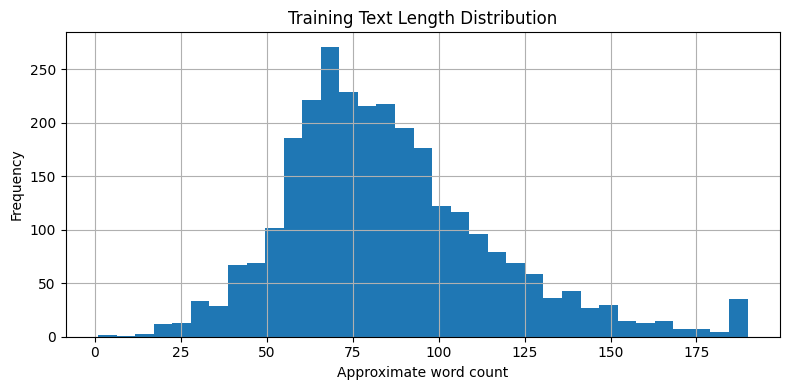

In [10]:
ax = train_df["word_count"].clip(
    upper=train_df["word_count"].quantile(0.99)
).hist(bins=35, figsize=(8, 4))
ax.set_title("Training Text Length Distribution")
ax.set_xlabel("Approximate word count")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## 5. Stratified training/validation split

The official test set remains untouched until final prototype evaluation.  
The cleaned training file is divided 80/20 using stratification and a fixed seed.

In [11]:
train_part, val_part = train_test_split(
    train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["label"],
)

train_part = train_part.reset_index(drop=True)
val_part = val_part.reset_index(drop=True)

split_summary = pd.DataFrame({
    "training": train_part["label"].value_counts().sort_index(),
    "validation": val_part["label"].value_counts().sort_index(),
})
split_summary.index = ["Non-stress (0)", "Stress (1)"]
split_summary

,training,validation
Non-stress (0),1069,267
Stress (1),1184,297


## 6. Reference models

The majority-class model establishes the minimum reference performance.  
The TF-IDF logistic-regression model tests whether contextual transformer fine-tuning provides a meaningful improvement over a traditional text classifier.

In [12]:
def metric_row(y_true, y_pred, y_prob=None, model_name="Model"):
    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_stress": precision_score(y_true, y_pred, zero_division=0),
        "Recall_stress": recall_score(y_true, y_pred, zero_division=0),
        "F1_stress": f1_score(y_true, y_pred, zero_division=0),
    }
    row["ROC_AUC"] = (
        roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    )
    return row

baseline_results = []

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(np.zeros((len(train_part), 1)), train_part["label"])
dummy_pred = dummy.predict(np.zeros((len(val_part), 1)))
baseline_results.append(
    metric_row(
        val_part["label"], dummy_pred,
        model_name="Majority class (validation)"
    )
)

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000,
    sublinear_tf=True,
)
X_train_tfidf = tfidf.fit_transform(train_part["clean_text"])
X_val_tfidf = tfidf.transform(val_part["clean_text"])

lr_model = LogisticRegression(
    C=2.0,
    max_iter=2000,
    class_weight=None,
    random_state=SEED,
)
lr_model.fit(X_train_tfidf, train_part["label"])
lr_val_pred = lr_model.predict(X_val_tfidf)
lr_val_prob = lr_model.predict_proba(X_val_tfidf)[:, 1]

baseline_results.append(
    metric_row(
        val_part["label"], lr_val_pred, lr_val_prob,
        "TF-IDF logistic regression (validation)"
    )
)

pd.DataFrame(baseline_results).round(4)

,Model,Accuracy,Precision_stress,Recall_stress,F1_stress,ROC_AUC
0,Majority class (validation),0.5266,0.5266,1.000,0.6899,NaN
1,TF-IDF logistic regression (validation),0.7677,0.7695,0.798,0.7835,0.8564


## 7. DistilBERT tokenization and dataset construction

The maximum sequence length is set to 256 subword tokens, consistent with Milestone B.  
Dynamic padding is used within each batch to reduce unnecessary computation.

In [13]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class DreadditDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tokenizer, max_length: int):
        self.texts = frame["clean_text"].tolist()
        self.labels = frame["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        encoded = self.tokenizer(
            self.texts[index],
            truncation=True,
            max_length=self.max_length,
            padding=False,
        )
        encoded["labels"] = self.labels[index]
        return encoded

train_dataset = DreadditDataset(train_part, tokenizer, MAX_LENGTH)
val_dataset = DreadditDataset(val_part, tokenizer, MAX_LENGTH)
test_dataset = DreadditDataset(test_df, tokenizer, MAX_LENGTH)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:", len(test_dataset))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Training examples: 2253
Validation examples: 564
Test examples: 715


## 8. Model construction and hyperparameters

DistilBERT contains six transformer encoder layers. A pretrained contextual representation is passed to a two-class sequence-classification head. Training uses AdamW through the Hugging Face Trainer, a learning rate of 2 × 10⁻⁵, weight decay, gradient clipping, three epochs, and early stopping based on validation F1.

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "NON_STRESS", 1: "STRESS"},
    label2id={"NON_STRESS": 0, "STRESS": 1},
)

trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters()
    if parameter.requires_grad
)
total_parameters = sum(parameter.numel() for parameter in model.parameters())

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(model)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 66,955,010
Trainable parameters: 66,955,010
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ff

In [15]:
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    probabilities = torch.softmax(
        torch.tensor(logits), dim=1
    ).numpy()[:, 1]
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(
            labels, predictions, zero_division=0
        ),
        "recall": recall_score(
            labels, predictions, zero_division=0
        ),
        "f1": f1_score(labels, predictions, zero_division=0),
        "roc_auc": roc_auc_score(labels, probabilities),
    }

training_args = TrainingArguments(
    output_dir="./milestone_c_distilbert",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.10,
    max_grad_norm=1.0,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=25,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

## 9. Model training

The following cell performs the actual fine-tuning. On a Colab T4 GPU, it should complete substantially faster than on a CPU.

In [16]:
train_output = trainer.train()
train_output

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.478100,0.490717,0.762411,0.702233,0.952862,0.808571,0.893492
2,0.348800,0.429427,0.804965,0.821306,0.804714,0.812925,0.894400
3,0.188000,0.471116,0.810284,0.808442,0.838384,0.823140,0.893775


TrainOutput(global_step=423, training_loss=0.3643352021562292, metrics={'train_runtime': 61.5751, 'train_samples_per_second': 109.768, 'train_steps_per_second': 6.87, 'total_flos': 328375556076540.0, 'train_loss': 0.3643352021562292, 'epoch': 3.0})

## 10. Training behavior

The learning curves below use the Trainer log history and show training loss, validation loss, and validation F1 across the run.

In [17]:
history = pd.DataFrame(trainer.state.log_history)
history.tail(10)

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_roc_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
10,0.3501,7.784874,0.000009,1.773050,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,0.3488,7.491393,0.000008,1.950355,275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,NaN,NaN,NaN,2.000000,282,0.429427,0.804965,0.821306,0.804714,0.812925,0.894400,0.8880,635.100,20.269,NaN,NaN,NaN,NaN,NaN
13,0.2407,7.333388,0.000007,2.127660,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,0.1931,5.193595,0.000005,2.304965,325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,0.2030,12.451371,0.000004,2.482270,350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,0.2251,7.030903,0.000003,2.659574,375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,0.1880,4.632802,0.000001,2.836879,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,NaN,NaN,NaN,3.000000,423,0.471116,0.810284,0.808442,0.838384,0.823140,0.893775,1.0615,531.329,16.957,NaN,NaN,NaN,NaN,NaN
19,NaN,NaN,NaN,3.000000,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.5751,109.768,6.87,3.283756e+14,0.364335


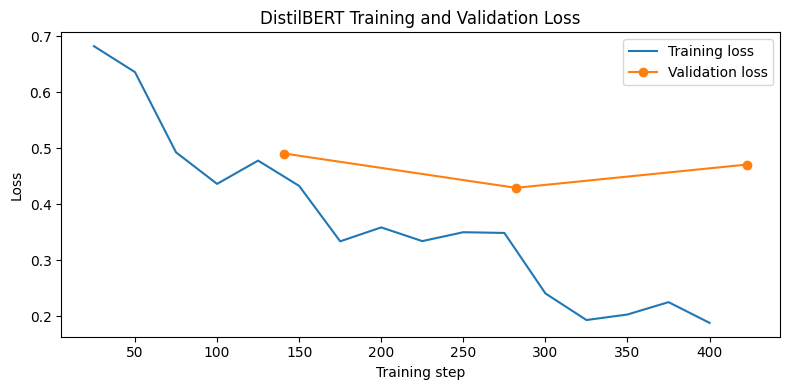

In [18]:
train_log = history.loc[
    history["loss"].notna() & history["eval_loss"].isna(),
    ["step", "loss"]
].copy()

eval_log = history.loc[
    history["eval_loss"].notna(),
    ["step", "epoch", "eval_loss", "eval_accuracy", "eval_f1"]
].copy()

fig, ax = plt.subplots(figsize=(8, 4))
if not train_log.empty:
    ax.plot(train_log["step"], train_log["loss"], label="Training loss")
if not eval_log.empty:
    ax.plot(eval_log["step"], eval_log["eval_loss"], marker="o", label="Validation loss")
ax.set_title("DistilBERT Training and Validation Loss")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

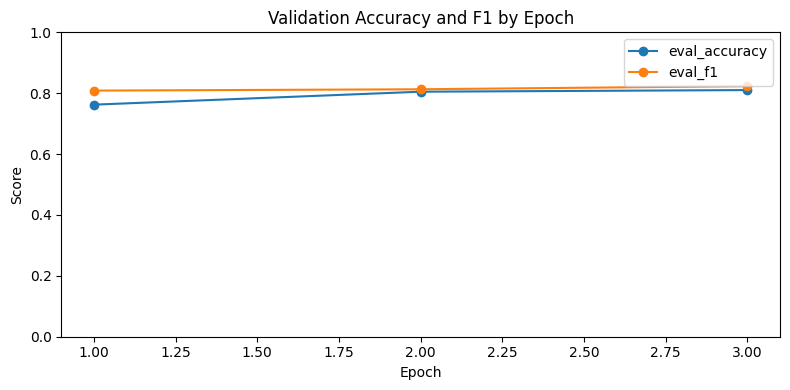

In [19]:
if not eval_log.empty:
    ax = eval_log.plot(
        x="epoch",
        y=["eval_accuracy", "eval_f1"],
        marker="o",
        figsize=(8, 4),
    )
    ax.set_title("Validation Accuracy and F1 by Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

## 11. Validation and held-out test evaluation

In [20]:
validation_metrics = trainer.evaluate(val_dataset)
validation_metrics

{'eval_loss': 0.471116304397583,
 'eval_accuracy': 0.8102836879432624,
 'eval_precision': 0.8084415584415584,
 'eval_recall': 0.8383838383838383,
 'eval_f1': 0.8231404958677686,
 'eval_roc_auc': 0.8937754574458694,
 'eval_runtime': 2.1141,
 'eval_samples_per_second': 266.785,
 'eval_steps_per_second': 8.514,
 'epoch': 3.0}

In [21]:
test_prediction_output = trainer.predict(test_dataset)
test_logits = test_prediction_output.predictions
test_probabilities = torch.softmax(
    torch.tensor(test_logits), dim=1
).numpy()[:, 1]
test_predictions = np.argmax(test_logits, axis=1)
y_test = test_df["label"].to_numpy()

test_metrics = metric_row(
    y_test,
    test_predictions,
    test_probabilities,
    model_name="DistilBERT (held-out test)"
)

results_table = pd.DataFrame(
    baseline_results + [test_metrics]
).round(4)
results_table

,Model,Accuracy,Precision_stress,Recall_stress,F1_stress,ROC_AUC
0,Majority class (validation),0.5266,0.5266,1.0000,0.6899,NaN
1,TF-IDF logistic regression (validation),0.7677,0.7695,0.7980,0.7835,0.8564
2,DistilBERT (held-out test),0.8084,0.7915,0.8537,0.8214,0.8783


In [22]:
print(classification_report(
    y_test,
    test_predictions,
    target_names=["Non-stress", "Stress"],
    digits=4,
))

              precision    recall  f1-score   support

  Non-stress     0.8297    0.7601    0.7934       346
      Stress     0.7915    0.8537    0.8214       369

    accuracy                         0.8084       715
   macro avg     0.8106    0.8069    0.8074       715
weighted avg     0.8099    0.8084    0.8078       715



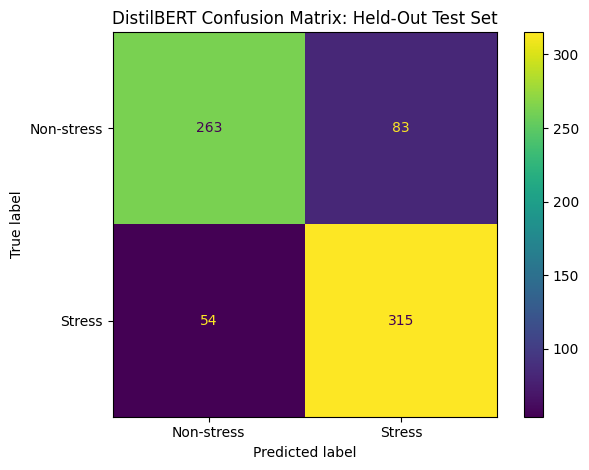

In [23]:
cm = confusion_matrix(y_test, test_predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-stress", "Stress"],
)
disp.plot(values_format="d")
plt.title("DistilBERT Confusion Matrix: Held-Out Test Set")
plt.tight_layout()
plt.show()

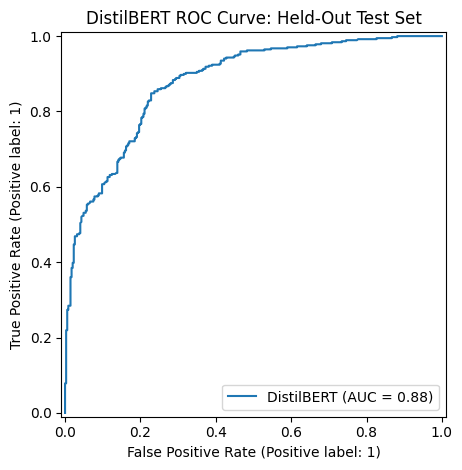

In [24]:
RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    name="DistilBERT",
)
plt.title("DistilBERT ROC Curve: Held-Out Test Set")
plt.tight_layout()
plt.show()

## 12. Sample predictions and preliminary error analysis

In [25]:
prediction_frame = test_df[
    ["subreddit", "clean_text", "label", "confidence"]
].copy()
prediction_frame["predicted_label"] = test_predictions
prediction_frame["stress_probability"] = test_probabilities
prediction_frame["correct"] = (
    prediction_frame["label"] == prediction_frame["predicted_label"]
)

sample_predictions = pd.concat([
    prediction_frame.loc[prediction_frame["correct"]].sample(
        min(3, prediction_frame["correct"].sum()),
        random_state=SEED
    ),
    prediction_frame.loc[~prediction_frame["correct"]].sample(
        min(3, (~prediction_frame["correct"]).sum()),
        random_state=SEED
    ),
]).sort_values("correct")

sample_predictions[
    ["subreddit", "label", "predicted_label",
     "stress_probability", "correct", "clean_text"]
].reset_index(drop=True)

,subreddit,label,predicted_label,stress_probability,correct,clean_text
0,ptsd,1,0,0.028008,False,I would like to reach out for help from someon...
1,almosthomeless,1,0,0.379953,False,As is usually the case with the stories I read...
2,ptsd,0,1,0.864425,False,I just wanted to say thank you to everyone tha...
3,domesticviolence,1,1,0.890485,True,What can I do best to support her? Are there r...
4,ptsd,1,1,0.978631,True,i have horrible vivid nightmares every night. ...
5,domesticviolence,1,1,0.901921,True,Ive been with my partner for a little over a y...


In [26]:
error_summary = (
    prediction_frame.loc[~prediction_frame["correct"]]
    .groupby(["subreddit", "label", "predicted_label"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False)
)
error_summary.head(15)

,subreddit,label,predicted_label,count
13,relationships,0,1,24
2,anxiety,0,1,16
14,relationships,1,0,15
11,ptsd,0,1,13
17,survivorsofabuse,0,1,10
9,homeless,0,1,9
12,ptsd,1,0,9
6,domesticviolence,0,1,7
3,anxiety,1,0,7
7,domesticviolence,1,0,7


## 13. Save model and export results

In [27]:
MODEL_DIR = Path("./AIT716_Milestone_C_DistilBERT")
MODEL_DIR.mkdir(exist_ok=True)

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
results_table.to_csv("milestone_c_results.csv", index=False)
prediction_frame.to_csv("milestone_c_test_predictions.csv", index=False)

print("Saved model to:", MODEL_DIR.resolve())
print("Saved metrics to milestone_c_results.csv")
print("Saved predictions to milestone_c_test_predictions.csv")

Saved model to: /content/AIT716_Milestone_C_DistilBERT
Saved metrics to milestone_c_results.csv
Saved predictions to milestone_c_test_predictions.csv


## 14. Preliminary Results Summary

The prototype completed successfully on the full Dreaddit pipeline. After leakage control and model fine-tuning, DistilBERT achieved the following preliminary results:

- **Validation accuracy:** 0.8103
- **Validation stress-class F1:** 0.8231
- **Validation ROC-AUC:** 0.8938
- **Held-out test accuracy:** 0.8084
- **Held-out stress precision:** 0.7915
- **Held-out stress recall:** 0.8537
- **Held-out stress F1:** 0.8214
- **Held-out ROC-AUC:** 0.8783
- **Confusion matrix:** 263 true negatives, 83 false positives, 54 false negatives, and 315 true positives

DistilBERT exceeded the TF-IDF logistic-regression validation baseline, which produced 0.7677 accuracy and a stress-class F1 of 0.7835. The transformer therefore added measurable value beyond the simpler bag-of-words representation.

The training trajectory indicates useful learning but also a mild late-epoch overfitting signal. Validation F1 improved from approximately 0.813 at epoch 2 to 0.823 at epoch 3, while validation loss rose from 0.429 to 0.471. This means the final epoch improved classification balance even though confidence calibration or generalization loss worsened slightly. Future experiments should compare the epoch-2 and epoch-3 checkpoints, tune the decision threshold, and test whether a smaller learning rate produces a more stable loss curve.

The model favored recall over precision for the stress class. It detected 315 of 369 stressful examples, yielding recall of 0.8537, but generated 83 false positives. Error counts were concentrated in communities such as relationships, anxiety, PTSD, and survivors of abuse, suggesting that difficult subject matter can resemble stressful self-disclosure even when the human label is non-stress. This behavior supports the intended use as an aggregate linguistic signal rather than an individual diagnostic judgment.

## 15. Prototype Completion Checklist

- [x] Dataset loading and preprocessing completed without errors.
- [x] Duplicate and overlap leakage checks returned zero after cleanup.
- [x] Majority and TF-IDF reference results were produced.
- [x] DistilBERT completed three epochs.
- [x] Training and validation curves were displayed.
- [x] Validation and held-out test metrics were produced.
- [x] Confusion matrix, ROC curve, and sample predictions were displayed.
- [x] The trained model, results table, and prediction file were exported.

### Interpretation boundaries

The classifier identifies patterns associated with human annotations of stressful language. It should not be interpreted as diagnosing an individual, representing the entire population, or proving a real-time change in societal mental health. Population-level use would require temporal aggregation, prevalence controls, drift monitoring, and external validation across platforms and demographic groups.

## References

Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *Proceedings of NAACL-HLT*, 4171–4186. https://doi.org/10.18653/v1/N19-1423

Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). DistilBERT, a distilled version of BERT: Smaller, faster, cheaper and lighter. *arXiv*. https://doi.org/10.48550/arXiv.1910.01108

Turcan, E., & McKeown, K. (2019). Dreaddit: A Reddit dataset for stress analysis in social media. *Proceedings of the Tenth International Workshop on Health Text Mining and Information Analysis*, 97–107. https://doi.org/10.18653/v1/D19-6213